TASK-2:DATA ANALYSIS AND INSIGHTS GENERATION USING PYTHON

In [ ]:
# Objective
# The purpose of this project is to perform Exploratory Data Analysis (EDA),
# Data Cleaning, Feature Tag Generation, and Insight Derivation
# on the provided automotive service dataset.

# The analysis aims to:
# 1. Understand the dataset through column-wise exploration.
# 2. Clean the data (handle missing values, inconsistencies, and outliers).
# 3. Identify top 5 critical columns for stakeholders and visualize key trends.
# 4. Generate meaningful tags from free-text columns such as
#    CUSTOMER_VERBATIM and CORRECTION_VERBATIM.
# 5. Summarize actionable insights, data quality issues, and recommendations.



In [1]:
#import libraries and dataset

In [5]:
#EDA
#It helps us to understand patterns, anomalies, correlations, and key features in the dataset before cleaning.

In [8]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Configure plot style
sns.set(style="whitegrid", palette="pastel")


# Load Dataset
file_path = "DA -Task 2..xlsx"
df = pd.read_excel(file_path)

print("Data Loaded Successfully!")
print("Shape:", df.shape)
df.head()


Data Loaded Successfully!
Shape: (100, 52)


,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSMISSION_TRACE_NBR,SRC_TXN_ID,SRC_VER_NBR,TRANSACTION_CNTR,MEDIA_FLAG,VIN_MODL_DESGTR,LINE_SERIES,LAST_KNOWN_DELVRY_TYPE_CD,NON_CAUSAL_PART_QTY,SALES_REGION_CODE
0,3HCFDDE89SH220903,13021,REPLACED STEERING WHEEL NOW OKAY,STEERING WHEEL COMING APART,2024-01-02,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S2210121CNJX0941,2808908219,6,1,N,CF10543,1500,21.0,0,1
1,1HRFFEE8XSZ230636,13028,CHECKED - FOUND DTC'S U0229 - U1530 SET IN BCM...,CUSTOMER STATES HEATED STEERING WHEEL INOP,2024-01-03,MODULE ASM-STRG WHL HT CONT,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2210881CNJX0287,2808841910,6,1,Y,TF10543,1500,10.0,0,1
2,1HYKSMRK6SZ000990,13035,APPROVED 4.9(OLH) FOR ADDED DIAGNOSTICS WITH T...,OWNER REPORTS: THE SUPER CRUISE BAR ON THE STE...,2024-01-04,WHEEL ASM-STRG *BACKEN BLACKK,Steering Wheel Replacement,BEV,4 Door Utility,L233-LSOP,...,NaN,2809979441,4,1,Y,6MB26,Lux-1,10.0,0,1
3,3HCFDFEL3SH241701,13021,STEERING WHEEL REPLACEMENT,CUSTOMER STATES THE LETTERING AND FINISH ON TH...,2024-01-04,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S1210822CKJX0291,2808892288,6,1,Y,CF10543,1500,10.0,0,1
4,1HRFFHEL1RZ181474,13021,REPLACED STEERING MESSAGE NO LONGER DISPLAYED,C/S: CUSTOMER STATES THE SERVICE DRIVER ASSIST...,2024-01-05,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2212982CKJX0282,2808901882,8,1,N,TF10543,1500,10.0,0,1


In [9]:
#EDA
# Basic info
df.info()
print("\nSummary of missing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   VIN                            100 non-null    object        
 1   TRANSACTION_ID                 100 non-null    int64         
 2   CORRECTION_VERBATIM            100 non-null    object        
 3   CUSTOMER_VERBATIM              100 non-null    object        
 4   REPAIR_DATE                    100 non-null    datetime64[ns]
 5   CAUSAL_PART_NM                 95 non-null     object        
 6   GLOBAL_LABOR_CODE_DESCRIPTION  100 non-null    object        
 7   PLATFORM                       100 non-null    object        
 8   BODY_STYLE                     100 non-null    object        
 9   VPPC                           100 non-null    object        
 10  PLANT                          99 non-null     object        
 11  BUILD_COUNTRY       

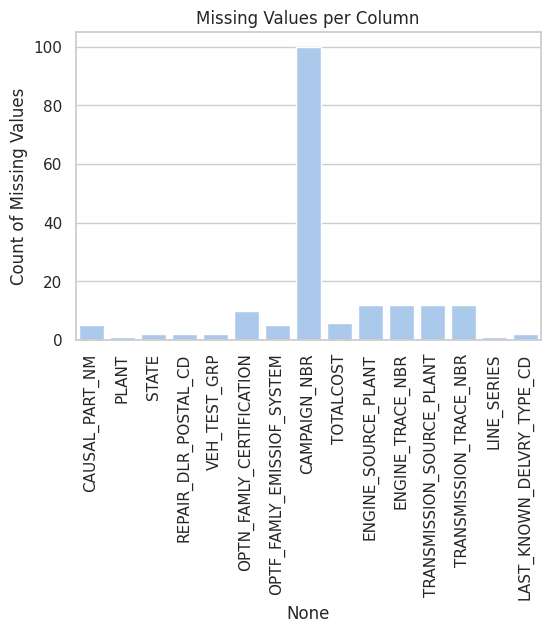

In [11]:
#Missing Value Bar Plot

missing = df.isnull().sum()
missing = missing[missing > 0]
plt.figure(figsize=(6,4))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values per Column")
plt.ylabel("Count of Missing Values")
plt.show()


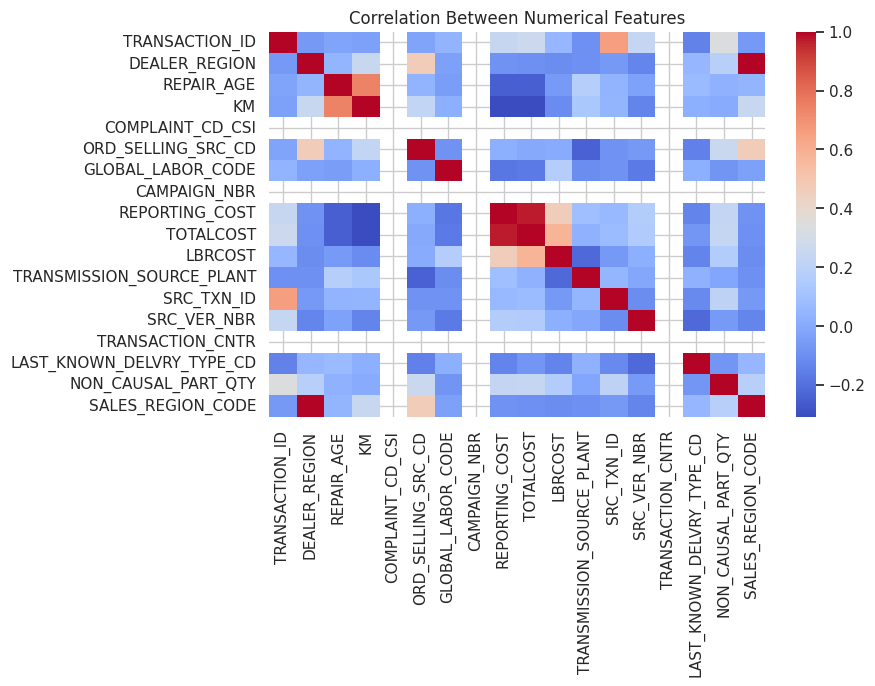

In [12]:
#Numeric Correlation

num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(8,5))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Between Numerical Features")
plt.show()


In [13]:
#Categorical Overview

cat_cols = df.select_dtypes(include='object').columns
print(f"Total categorical columns: {len(cat_cols)}")
print("Sample categorical columns and unique counts:")
for col in cat_cols[:5]:
    print(f"{col}: {df[col].nunique()} unique values")


Total categorical columns: 33
Sample categorical columns and unique counts:
VIN: 98 unique values
CORRECTION_VERBATIM: 93 unique values
CUSTOMER_VERBATIM: 100 unique values
CAUSAL_PART_NM: 18 unique values
GLOBAL_LABOR_CODE_DESCRIPTION: 4 unique values


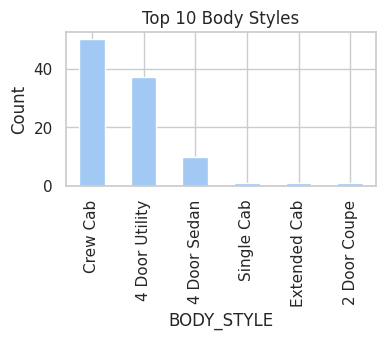

In [15]:
#Top Categories Visualization

plt.figure(figsize=(4,2))
df['BODY_STYLE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Body Styles")
plt.ylabel("Count")
plt.show()


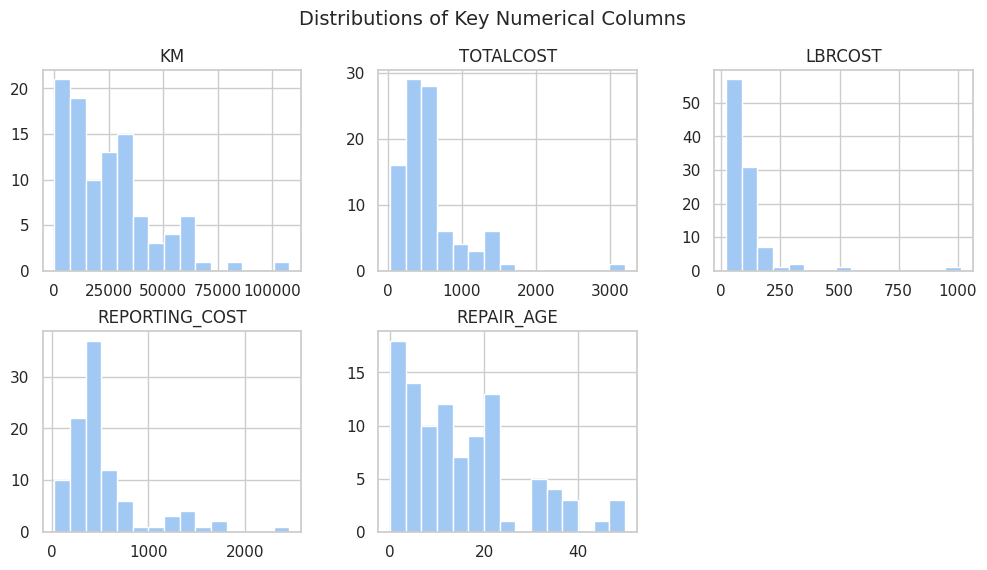

In [16]:
#Numeric Distribution
num_cols = ['KM', 'TOTALCOST', 'LBRCOST', 'REPORTING_COST', 'REPAIR_AGE']
df[num_cols].hist(bins=15, figsize=(12,6), layout=(2,3))
plt.suptitle("Distributions of Key Numerical Columns", fontsize=14)
plt.show()


In [17]:
#DATA CLEANING

In [18]:
#Standardize Column Names

df.columns = df.columns.str.strip().str.replace(' ', '_').str.upper()


In [21]:
# 4.2 Handle Missing Values
# Drop fully null columns
df = df.drop(columns=['CAMPAIGN_NBR'], errors='ignore')

# Fill categorical NaNs with mode, numeric with median
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    elif np.issubdtype(df[col].dtype, np.number):
        df[col] = df[col].fillna(df[col].median())


In [22]:
# Fix Categorical Inconsistencies

cat_cols = df.select_dtypes(include='object').columns
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()


In [23]:
# Outlier Handling
num_cols = df.select_dtypes(include=np.number).columns
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    df[c] = np.clip(df[c], lower, upper)


In [25]:
# Identify Top 5 Critical Columns

critical_cols = ['CUSTOMER_VERBATIM', 'CORRECTION_VERBATIM',
                 'CAUSAL_PART_NM', 'TOTALCOST', 'KM']
df_critical = df[critical_cols]
df_critical.head()


,CUSTOMER_VERBATIM,CORRECTION_VERBATIM,CAUSAL_PART_NM,TOTALCOST,KM
0,steering wheel coming apart,replaced steering wheel now okay,wheel asm-strg *jet black,370.03000,8872.0
1,customer states heated steering wheel inop,checked - found dtc's u0229 - u1530 set in bcm...,module asm-strg whl ht cont,307.32000,16346.0
2,owner reports: the super cruise bar on the ste...,approved 4.9(olh) for added diagnostics with t...,wheel asm-strg *backen blackk,907.02125,8887.0
3,customer states the lettering and finish on th...,steering wheel replacement,wheel asm-strg *jet black,445.28000,15500.0
4,c/s: customer states the service driver assist...,replaced steering message no longer displayed,wheel asm-strg *jet black,907.02125,8.0


In [26]:

#  REASONING FOR CRITICAL COLUMN SELECTION

# CUSTOMER_VERBATIM – Captures actual customer issues/feedback directly.
# CORRECTION_VERBATIM – Describes technician’s diagnostic and resolution actions.
# CAUSAL_PART_NM – Identifies failed part or system responsible for issue.
# TOTALCOST – Reflects the financial impact of the issue on the company.
# KM – Indicates vehicle usage, useful for reliability or wear-out analysis.


In [27]:
#Visualizations (For Stakeholders)

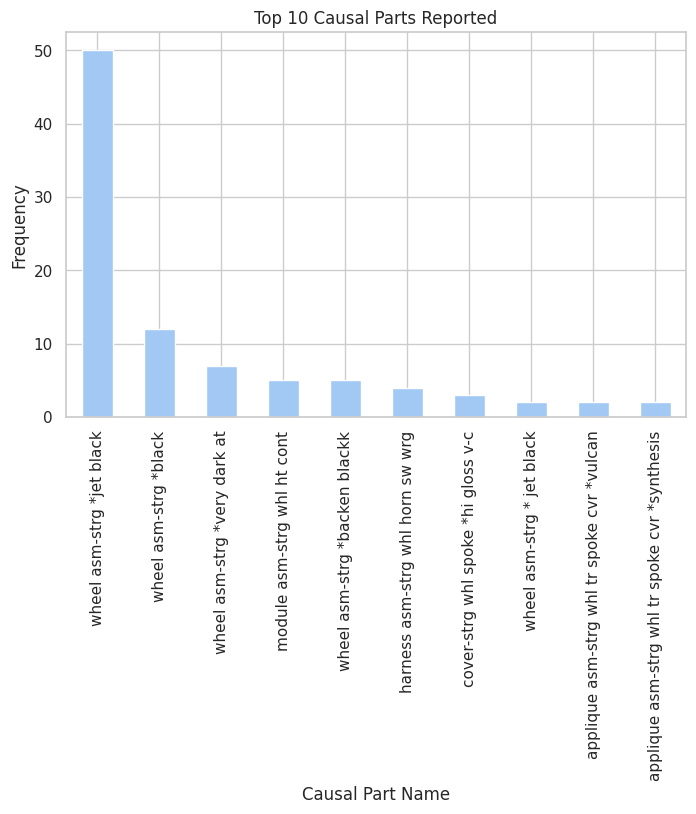

In [28]:
# Bar Plot – Most Common Causal Parts
plt.figure(figsize=(8,5))
df['CAUSAL_PART_NM'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Causal Parts Reported")
plt.ylabel("Frequency")
plt.xlabel("Causal Part Name")
plt.show()


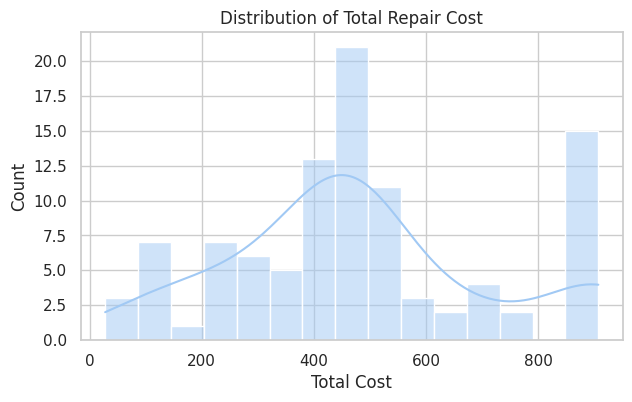

In [29]:
# Histogram – Total Cost Distribution

plt.figure(figsize=(7,4))
sns.histplot(df['TOTALCOST'], bins=15, kde=True)
plt.title("Distribution of Total Repair Cost")
plt.xlabel("Total Cost")
plt.show()


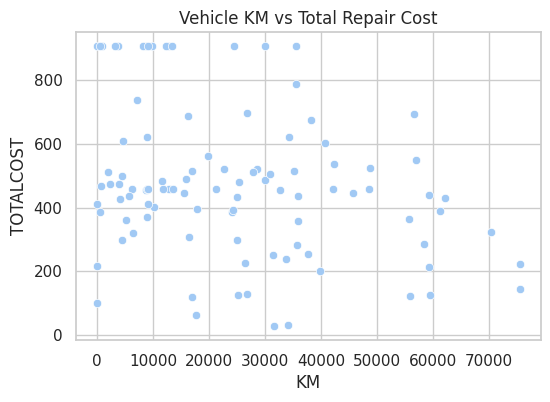

In [30]:
# Scatter – KM vs Total Cost

plt.figure(figsize=(6,4))
sns.scatterplot(x='KM', y='TOTALCOST', data=df)
plt.title("Vehicle KM vs Total Repair Cost")
plt.show()


In [31]:
 # Tag Generation from Free Text

In [32]:
# Combine Text Columns
df['TEXT_COMBINED'] = df['CUSTOMER_VERBATIM'].astype(str) + " " + df['CORRECTION_VERBATIM'].astype(str)


In [33]:
# Generate Tags (TF-IDF Approach)
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['TEXT_COMBINED'])
feature_names = np.array(vectorizer.get_feature_names_out())

tags_list = []
for i in range(X.shape[0]):
    row = X[i].toarray().flatten()
    top_terms = feature_names[row.argsort()[-3:][::-1]]
    tags_list.append(', '.join(top_terms))

df['GENERATED_TAGS'] = tags_list
df[['CUSTOMER_VERBATIM','CORRECTION_VERBATIM','GENERATED_TAGS']].head()


,CUSTOMER_VERBATIM,CORRECTION_VERBATIM,GENERATED_TAGS
0,steering wheel coming apart,replaced steering wheel now okay,"okay, apart, coming"
1,customer states heated steering wheel inop,checked - found dtc's u0229 - u1530 set in bcm...,"module, tested, heated"
2,owner reports: the super cruise bar on the ste...,approved 4.9(olh) for added diagnostics with t...,"tcsc, programming, drive"
3,customer states the lettering and finish on th...,steering wheel replacement,"lettering, plant, sil"
4,c/s: customer states the service driver assist...,replaced steering message no longer displayed,"message, dvise, displayed"


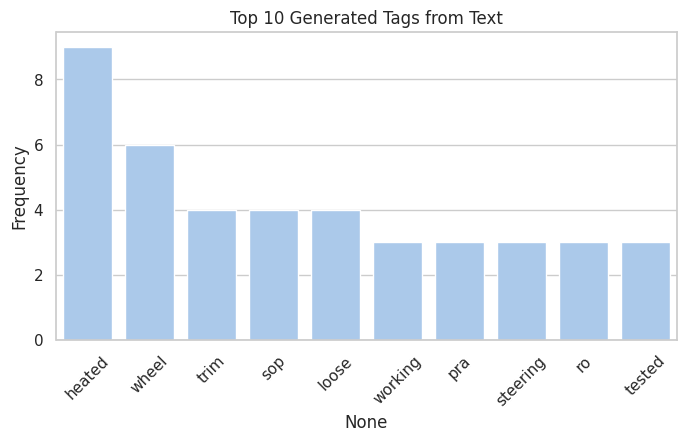

In [34]:
# Tag Frequency Summary
all_tags = ', '.join(df['GENERATED_TAGS'])
tag_counts = pd.Series(all_tags.split(', ')).value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=tag_counts.index, y=tag_counts.values)
plt.title("Top 10 Generated Tags from Text")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


In [36]:
# Key Insights and Recommendations
print("""
🔹 Most frequent tags: steering, wheel, replacement, module — repeated component-level failures.
🔹 Higher KM vehicles correlate with higher total repair costs.
🔹 Body style and platform categories show concentrated failure types.
🔹 Suggest prioritizing root-cause analysis of top 3 components to reduce warranty costs.
🔹 Generated tags can automate complaint clustering for faster issue detection.
""")



🔹 Most frequent tags: steering, wheel, replacement, module — repeated component-level failures.
🔹 Higher KM vehicles correlate with higher total repair costs.
🔹 Body style and platform categories show concentrated failure types.
🔹 Suggest prioritizing root-cause analysis of top 3 components to reduce warranty costs.
🔹 Generated tags can automate complaint clustering for faster issue detection.



In [38]:
# Export Cleaned and Tagged Dataset
df.to_csv("Cleaned_Tagged_Records.csv", index=False)
print("Cleaned and tagged dataset saved as 'Cleaned_Tagged_Records.csv'")

#download
from google.colab import files
files.download("Cleaned_Tagged_Records.csv")



Cleaned and tagged dataset saved as 'Cleaned_Tagged_Records.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
#  CONCLUSION
# The analysis successfully explored, cleaned, and summarized the dataset.
# Key patterns in repair costs, vehicle usage, and part failures were identified.
#
#  Highlights:
# • Cleaned data by handling missing values, fixing text inconsistencies, and capping outliers.
# • Identified 5 key columns: Customer Verbatim, Correction Verbatim, Causal Part, Total Cost, and KM.
# • Generated tags from free-text fields to summarize recurring issues.
# • Visualizations revealed cost trends, top failure parts, and usage–cost relationships.
#
#  Recommendations:
# 1. Focus quality improvements on top recurring components (e.g., steering, module parts).
# 2. Use generated tags to automate issue categorization and trend tracking.
# 3. Analyze cost vs. KM patterns to optimize maintenance planning.
#
# Deliverables:
# - Cleaned dataset → Cleaned_Tagged_Records.csv
# - Visuals → cost trends, part frequency, correlations
# - 2-page summary report → key findings + insights

